In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shrutimechlearn/churn-modelling")

print("Path to dataset files:", path)


100%|██████████| 262k/262k [00:00<00:00, 811kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/shrutimechlearn/churn-modelling/versions/1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os

In [3]:
os.path.join(path,'Churn_Modelling.csv')

'/root/.cache/kagglehub/datasets/shrutimechlearn/churn-modelling/versions/1/Churn_Modelling.csv'

In [4]:

df = pd.read_csv(os.path.join(path, 'Churn_Modelling.csv'))

In [5]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.shape

(10000, 14)

In [7]:
# we have to predict if the cuteomer will exit based on other data given about him ...

In [8]:

# select input and output features

X = df.iloc[:,3:-1]
Y = df.iloc[:,-1]


In [9]:
# Data Preprocessing

geography = pd.get_dummies(X['Geography'],drop_first=True, dtype=int)
gender = pd.get_dummies(X['Gender'],drop_first=True, dtype=int)

In [10]:
X.drop(['Geography','Gender'],axis=1,inplace=True)

In [11]:
# concatinate the new engineered columns deleted

X = pd.concat([X,geography,gender],axis =1)

In [12]:
X.shape

(10000, 11)

In [13]:
# Spliiting the dataset in train , test
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

In [14]:
# Feature scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [15]:
X_train.shape

(8000, 11)

In [16]:
## Implementing ANN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU,PReLU,ELU,ReLU
from tensorflow.keras.layers import Dropout


In [17]:
### LEts intilize the ANN
classifier = Sequential()

In [18]:
## Adding the input layer
classifier.add(Dense(units = 11, activation = 'relu'))

In [19]:
##Adding the first hidden layer
classifier.add(Dense(units = 7, activation = 'relu'),Dropout(0.3))

In [20]:
##Adding the second hidden layer
classifier.add(Dense(units = 6, activation = 'relu'))

In [21]:
## adding output layer
classifier.add(Dense(units = 1, activation = 'sigmoid'))

In [22]:
## Early Stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
)


In [23]:
classifier.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [24]:
model_history = classifier.fit(X_train,Y_train,validation_split=0.33,batch_size=10,epochs=1000,callbacks=early_stopping)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7962 - loss: 0.4975 - val_accuracy: 0.7955 - val_loss: 0.4504
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7962 - loss: 0.4379 - val_accuracy: 0.7955 - val_loss: 0.4341
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7962 - loss: 0.4244 - val_accuracy: 0.7955 - val_loss: 0.4278
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8048 - loss: 0.4158 - val_accuracy: 0.8103 - val_loss: 0.4233
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8240 - loss: 0.4085 - val_accuracy: 0.8186 - val_loss: 0.4168
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8343 - loss: 0.3992 - val_accuracy: 0.8236 - val_loss: 0.4072
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8466 - loss: 0.3838 - val_accuracy: 0.8360 - val_loss: 0.3921
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8533 - loss: 0.3659 - 

In [25]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

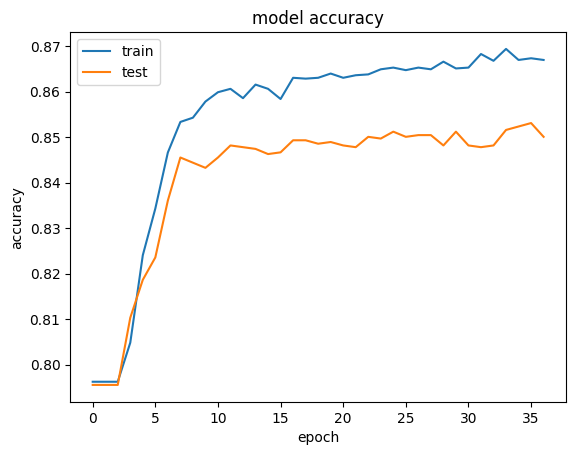

In [26]:
## plot for the parameters and  training
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

In [27]:
##Predicting for the test data
Y_pred = classifier.predict(X_test)
Y_pred = (Y_pred > 0.5)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [28]:
## make the confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test,Y_pred)
cm


array([[1490,  105],
       [ 192,  213]])

In [29]:
## Calculate the accuracy
from sklearn.metrics import accuracy_score
score = accuracy_score(Y_pred,Y_test)
score

0.8515

In [30]:
pip install keras-tuner --upgrade


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 2.9 MB/s eta 0:00:00


In [31]:
def build_model(hp):
  model = Sequential()

  for i in range(hp.Int('layers', min_value=2, max_value=20, step=1)):
    model.add(Dense(units=hp.Int('units_' + str(i),
                                 min_value=32,
                                 max_value=512,
                                 step=32),
                    activation=hp.Choice('activation_' + str(i), ['relu', 'tanh', 'sigmoid'])))
    model.add(Dropout(rate=hp.Float('dropout_rate_' + str(i), min_value=0.0, max_value=0.5, step=0.1)))

  model.add(Dense(1, activation='sigmoid'))

  optimizer_name = hp.Choice('optimizer_type', ['Adam', 'Adagrad', 'RMSprop'])
  learning_rate = hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])

  if optimizer_name == 'Adam':
      optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
  elif optimizer_name == 'Adagrad':
      optimizer = keras.optimizers.Adagrad(learning_rate=learning_rate)
  elif optimizer_name == 'RMSprop':
      optimizer = keras.optimizers.RMSprop(learning_rate=learning_rate)
  else:
      optimizer = keras.optimizers.Adam(learning_rate=learning_rate) # Fallback

  model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
  return model

In [32]:
import keras_tuner as kt
from keras_tuner.tuners import RandomSearch
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [33]:
tuner = kt.RandomSearch(build_model,objective='val_accuracy',max_trials=3,executions_per_trial=3,directory='project',project_name='Churn')

In [34]:
tuner.search_space_summary()

Search space summary
Default search space size: 9
layers (Int)
{'default': None, 'conditions': [], 'min_value': 2, 'max_value': 20, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 512, 'step': 32, 'sampling': 'linear'}
activation_0 (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh', 'sigmoid'], 'ordered': False}
dropout_rate_0 (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
units_1 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 512, 'step': 32, 'sampling': 'linear'}
activation_1 (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh', 'sigmoid'], 'ordered': False}
dropout_rate_1 (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
optimizer_type (Choice)
{'default': 'Adam', 'conditions': [], 'values': ['Adam', 'Adagrad', 'RMSprop'], '

In [35]:
tuner.search(X_train,Y_train,epochs=5,validation_data=(X_test,Y_test), callbacks=[early_stopping])

Trial 3 Complete [00h 00m 38s]
val_accuracy: 0.8084999918937683

Best val_accuracy So Far: 0.8615000049273173
Total elapsed time: 00h 01m 24s


In [36]:
tuner.get_best_hyperparameters()[0].values

{'layers': 4,
 'units_0': 448,
 'activation_0': 'relu',
 'dropout_rate_0': 0.1,
 'units_1': 96,
 'activation_1': 'tanh',
 'dropout_rate_1': 0.0,
 'optimizer_type': 'Adam',
 'learning_rate': 0.01,
 'units_2': 288,
 'activation_2': 'tanh',
 'dropout_rate_2': 0.4,
 'units_3': 480,
 'activation_3': 'relu',
 'dropout_rate_3': 0.0,
 'units_4': 320,
 'activation_4': 'tanh',
 'dropout_rate_4': 0.30000000000000004}

In [37]:
model = tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [38]:
model.fit(X_train,Y_train,epochs=100,validation_data=(X_test,Y_test),callbacks=[early_stopping])

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8419 - loss: 0.3869 - val_accuracy: 0.8655 - val_loss: 0.3507
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8485 - loss: 0.3766 - val_accuracy: 0.8510 - val_loss: 0.3576
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8509 - loss: 0.3720 - val_accuracy: 0.8420 - val_loss: 0.3717
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8481 - loss: 0.3722 - val_accuracy: 0.8660 - val_loss: 0.3663
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8497 - loss: 0.3656 - val_accuracy: 0.8645 - val_loss: 0.3548
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8560 - loss: 0.3621 - val_accuracy: 0.8525 - val_loss: 0.3659


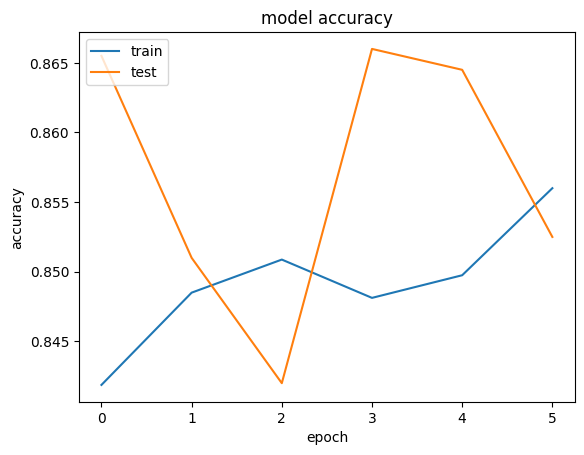

In [39]:
## plot for the parameters and  training
plt.plot(model.history['accuracy'])
plt.plot(model.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

In [40]:
# predict over test data
Y_pred = model.predict(X_test)
Y_pred = (Y_pred > 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [41]:
from sklearn.metrics import accuracy_score,confusion_matrix
score = accuracy_score(Y_test,Y_pred)
score
#cm= confusion_matrix(Y_test,Y_pred)
#cm

0.8525